# Evaluate RAG

## 1. Imports & Setup

All imports are consolidated here. Paths are configured, environment variables loaded, and `experiments` is added to `sys.path` so we can import `utils.models` and `utils.prompts`.

*Run the setup cell below before continuing.*

In [1]:
# --- Standard library ---
import json
import sys
from collections import defaultdict
from pathlib import Path

# --- Third-party ---
from dotenv import load_dotenv
from chromadb import PersistentClient
from litellm import completion
from openai import OpenAI
from pydantic import BaseModel, Field
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tabulate import tabulate

# --- Path setup (find backend/data/vector_db; works from repo root or experiments/notebooks) ---
_cwd = Path.cwd()
_candidates = [_cwd, _cwd.parent, _cwd.parent.parent]
VECTOR_DB_PATH = None
for root in _candidates:
    p = root / "backend" / "data" / "vector_db"
    if p.exists():
        VECTOR_DB_PATH = p
        break
if VECTOR_DB_PATH is None:
    VECTOR_DB_PATH = _cwd / "backend" / "data" / "vector_db"

EXPERIMENTS_PATH = VECTOR_DB_PATH.parent.parent.parent / "experiments"  # experiments/
BACKEND_PATH = VECTOR_DB_PATH.parent.parent  # backend/

if str(EXPERIMENTS_PATH) not in sys.path:
    sys.path.insert(0, str(EXPERIMENTS_PATH))

# Load environment variables from backend/.env if it exists;
# otherwise, load system environment variables with default behavior
env_path = BACKEND_PATH / ".env"
if env_path.exists():
    load_dotenv(env_path, override=True)
    print(f"[OK] Loaded environment variables from {env_path}")
else:
    load_dotenv(override=True)
    print("[WARNING] Backend .env not found, using default environment")

# --- Project imports (after path is set) ---
from utils.models import AnswerEval, QAPairWithTS, Result
from utils.prompts import (
    EVALUATE_ANSWER_SYSTEM_PROMPT,
    RAG_SYSTEM_PROMPT,
    RERANK_CHUNKS_SYSTEM_PROMPT,
    REWRITE_QUERY_SYSTEM_PROMPT,
)

# --- Constants ---
COLLECTION_NAME = "docs"
EMBEDDING_MODEL = "text-embedding-3-large"

print(f"DB path: {VECTOR_DB_PATH}")
print(f"Exists: {VECTOR_DB_PATH.exists()}")

[OK] Loaded environment variables from c:\Users\smvan\repos\madetech-rag-assistant\backend\.env
DB path: c:\Users\smvan\repos\madetech-rag-assistant\backend\data\vector_db
Exists: True


## 2. Connect to ChromaDB

Open the vector database and verify the collection.

---

In [2]:
# Connect to ChromaDB and verify the collection
chroma = PersistentClient(path=str(VECTOR_DB_PATH))
collection = chroma.get_collection(COLLECTION_NAME)
print(f"Collection '{COLLECTION_NAME}' has {collection.count()} chunks")

Collection 'docs' has 1637 chunks


## 3. Basic Retrieval (Semantic Search)

Embed a query, retrieve the top-k similar chunks, and inspect results. This tests retrieval without using an LLM.

In [3]:
# Test semantic search: embed query and retrieve similar chunks
client = OpenAI()
query = "What cycling benefits do we have?"
query_embedding = client.embeddings.create(
    model=EMBEDDING_MODEL, input=[query]
).data[0].embedding

results = collection.query(
    query_embeddings=[query_embedding],
    n_results=10,
    include=["documents", "metadatas", "distances"],
)

print(f"Query: {query}\n")
for i, (doc, meta, dist) in enumerate(zip(
    results["documents"][0],
    results["metadatas"][0],
    results["distances"][0],
), 1):
    print(f"--- Result {i} (distance={dist:.4f}) ---")
    print(f"Metadata: {meta}")
    print(f"Content preview: {doc[:200]}...")
    print()

Query: What cycling benefits do we have?

--- Result 1 (distance=0.9271) ---
Metadata: {'category': 'Benefits', 'id': 'benefits-cycle_to_work_scheme', 'title': 'Cycle To Work'}
Content preview: Headline: CycleScheme Benefits
Summary: CycleScheme provides cost-effective cycling equipment via salary sacrifice, saving 25‑39% on tax and NI, with monthly deductions over 12 months and no large upf...

--- Result 2 (distance=1.0282) ---
Metadata: {'category': 'Benefits', 'id': 'benefits-cycle_to_work_scheme', 'title': 'Cycle To Work'}
Content preview: Headline: Cycle To Work Overview
Summary: Made Tech offers a Cycle to Work scheme using CycleScheme up to £2500, allowing employees to hire a bike and accessories via salary sacrifice over 12 months, ...

--- Result 3 (distance=1.1143) ---
Metadata: {'title': 'Cycle To Work', 'id': 'benefits-cycle_to_work_scheme', 'category': 'Benefits'}
Content preview: Headline: Comparison to Interest‑Free Finance
Summary: CycleScheme offers greater tax and NI

## 4. RAG Pipeline

Define the RAG pipeline: query rewriting, multi-query retrieval, chunk merging, LLM reranking, and answer generation.

### Run RAG

Quick test: ask a question and generate an answer.


In [4]:
# RAG components: client, retrieval params, and pipeline functions
openai = OpenAI()
RETRIEVAL_K = 10
FINAL_K = 7

def fetch_context_unranked(question):
    query = openai.embeddings.create(model=EMBEDDING_MODEL, input=[question]).data[0].embedding
    results = collection.query(query_embeddings=[query], n_results=RETRIEVAL_K)
    chunks = []
    for result in zip(results["documents"][0], results["metadatas"][0]):
        chunks.append(Result(page_content=result[0], metadata=result[1]))
    return chunks


def rewrite_query(question, history=[]):
    """Rewrite the user's question to be a more specific question that is more likely to surface relevant content in the Knowledge Base."""
    message = REWRITE_QUERY_SYSTEM_PROMPT.format(history=history, question=question)
    response = completion(model=MODEL, messages=[{"role": "system", "content": message}])
    return response.choices[0].message.content

def merge_chunks(chunks_1, chunks_2):
    merged = chunks_1[:]
    existing = [chunk.page_content for chunk in chunks_1]
    for chunk in chunks_2:
        if chunk.page_content not in existing:
            merged.append(chunk)
    return merged

class RankOrder(BaseModel):
    order: list[int] = Field(
        description="The order of relevance of chunks, from most relevant to least relevant, by chunk id number"
    )


def _repair_concatenated_order(concatenated: int, n: int) -> list[int] | None:
    """Recover order from LLM output like 124936781011121314151617 when it forgets commas."""
    s = str(concatenated)
    result = []
    i = 0
    valid = set(range(1, n + 1))
    used = set()
    while i < len(s) and len(result) < n:
        one = int(s[i])
        two_val = int(s[i : i + 2]) if i + 1 < len(s) else None
        # Prefer 1 digit first so "12" -> [1,2] not [12]
        if one in valid and one not in used:
            result.append(one)
            used.add(one)

            i += 2
        else:
            return None
    return result if len(result) == n and i == len(s) else None


# @retry(wait=wait)
def rerank(question, chunks):
    n = len(chunks)
    valid_ids = set(range(1, n + 1))
    system_prompt = RERANK_CHUNKS_SYSTEM_PROMPT
    user_prompt = f"The user has asked the following question:\n\n{question}\n\nOrder all {n} chunks by relevance, from most to least relevant. Include every chunk ID from 1 to {n} exactly once.\n\n"
    user_prompt += "Here are the chunks:\n\n"
    for index, chunk in enumerate(chunks):
        user_prompt += f"# CHUNK ID: {index + 1}:\n\n{chunk.page_content}\n\n"
    user_prompt += f"Reply with valid JSON only: {{\"order\": [a, b, c, ...]}} with {n} comma-separated integers."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    response = completion(model=MODEL, messages=messages, response_format=RankOrder)
    reply = response.choices[0].message.content
    parsed = RankOrder.model_validate_json(reply)
    order = parsed.order
    # Validate: must have n elements, each 1..n exactly once
    if len(order) == n and set(order) == valid_ids:
        return [chunks[i - 1] for i in order]
    # Repair: LLM sometimes returns concatenated numbers without commas, e.g. [124936781011121314151617]
    if len(order) == 1 and isinstance(order[0], int) and order[0] > 9:
        repaired = _repair_concatenated_order(order[0], n)
        if repaired is not None:
            return [chunks[i - 1] for i in repaired]
    return [chunks[i - 1] for i in list(range(1, n + 1))]  # fallback to original order

def fetch_context(original_question, history):
    rewritten_question = rewrite_query(original_question, history)
    chunks1 = fetch_context_unranked(original_question)
    chunks2 = fetch_context_unranked(rewritten_question)
    chunks = merge_chunks(chunks1, chunks2)
    reranked = rerank(original_question, chunks)
    return reranked[:FINAL_K]


def make_rag_messages(question, history, chunks):
    context = "\n\n---\n\n".join(
        f"Extract from ({chunk.metadata['category']}) — {chunk.metadata['title']}:\n{chunk.page_content}" for chunk in chunks
    )
    system_prompt = RAG_SYSTEM_PROMPT.format(context=context)
    return (
        [{"role": "system", "content": system_prompt}]
        + history
        + [{"role": "user", "content": question}]
    )

MODEL = 'groq/openai/gpt-oss-20b'

def answer_question(question: str, history: list[dict] = []) -> tuple[str, list]:
    """
    Answer a question using RAG and return the answer and the retrieved context
    """
    chunks = fetch_context(question, history)
    messages = make_rag_messages(question, history, chunks)
    response = completion(model=MODEL, messages=messages)
    return response.choices[0].message.content, chunks

In [5]:
answer, chunks = answer_question("What cycling benefits do I have?")
# print(answer)

## 5. Load Evaluation Questions

Load QA pairs from `validation.jsonl` (from the latest run in `00_questions_generation/output`).

In [6]:
# Load eval questions from validation.jsonl (latest timestamp in 00_questions_generation/output)
QUESTIONS_OUTPUT = EXPERIMENTS_PATH / "scripts" / "00_questions_generation" / "output"
_latest_dir = max((d for d in QUESTIONS_OUTPUT.iterdir() if d.is_dir()), key=lambda d: d.name)
EVAL_QUESTIONS_FILE = _latest_dir / "validation.jsonl"


def load_eval_questions() -> list[QAPairWithTS]:
    """Load eval questions from JSONL file."""
    questions = []
    with open(EVAL_QUESTIONS_FILE, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line.strip())
            questions.append(QAPairWithTS(**data))
    return questions


questions = load_eval_questions()
print(f"Loaded {len(questions)} questions from {EVAL_QUESTIONS_FILE}")

Loaded 195 questions from c:\Users\smvan\repos\madetech-rag-assistant\experiments\scripts\00_questions_generation\output\2026-03-05_07-47-14\validation.jsonl


In [7]:
questions[:3]

[QAPairWithTS(question='What steps must I take to lock my screen during the DSE/H&S training session, especially if I’m using multiple monitors?', answer='Before leaving your workstation, lock each monitor’s screen and enable automatic screen lock. If using multiple screens, make sure no confidential information is displayed on any of them and that the workstation remains off when idle.', question_type='multi-source', doc_metadata=[HandbookDocMetadata(id='guides-welfare-dse_hs_training', title='DSE & Health & Safety Training', category='Guides'), HandbookDocMetadata(id='guides-office-clear_desk_clear_screen', title='Clear Desk/Clear Screen', category='Guides')]),
 QAPairWithTS(question='What are the main responsibilities of a Delivery Director at Made Tech?', answer='A Delivery Director leads delivery across multiple clients, manages senior client relationships, oversees a portfolio with revenue over £10\u202fmillion, and ensures successful project execution, client delight, and team e

## 6. Answer Evaluation (LLM-as-Judge)

Evaluate each RAG answer using an LLM judge that scores accuracy, completeness, and relevance against the reference answer.

In [8]:
# LLM-as-judge: compare generated answer to reference and return structured scores
def evaluate_answer(test: QAPairWithTS) -> tuple[AnswerEval, str, list]:
    """
    Evaluate answer quality using LLM-as-a-judge (async).

    Args:
        test: TestQuestion object containing question and reference answer

    Returns:
        Tuple of (AnswerEval object, generated_answer string, retrieved_docs list)
    """
    # Get RAG response using shared answer module
    generated_answer, retrieved_docs = answer_question(test.question)

    user_prompt = (
        f"""The user has provided the following:
        
        [QUESTION BEGINS]
        {test.question}
        [QUESTION ENDS]

        [GENERATED ANSWER BEGINS]
        {generated_answer}
        [GENERATED ANSWER ENDS]

        [REFERENCE ANSWER BEGINS]
        {test.answer}
        [REFERENCE ANSWER ENDS]

        Reply with your feedback and your scores for accuracy, completeness, and relevance, nothing else."""
    )

    # LLM judge prompt
    judge_messages = [
        {
            "role": "system",
            "content": EVALUATE_ANSWER_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    # Call LLM judge with structured outputs (async)
    judge_response = completion(model=MODEL, messages=judge_messages, response_format=AnswerEval)

    answer_eval = AnswerEval.model_validate_json(judge_response.choices[0].message.content)

    return answer_eval, generated_answer, retrieved_docs


In [10]:
# Run evaluation loop over questions (adjust slice to evaluate more/fewer)
accuracies = []
completenesses = []
relevances = []
question_types = []

for qa in tqdm(questions[:10], desc="Evaluating answers"):
    # Optionally: You could use qa.question_type if logic needs to be distinguished
    eval_result, generated_answer, retrieved_docs = evaluate_answer(qa)
    accuracies.append(eval_result.accuracy)
    completenesses.append(eval_result.completeness)
    relevances.append(eval_result.relevance)
    question_types.append(qa.question_type)

Evaluating answers:   0%|          | 0/10 [00:00<?, ?it/s]

## 7. Results

Summary statistics and visualizations of the evaluation scores.

In [11]:
# Summary statistics: mean, median, std, min, max per metric
print("=" * 37)
print("         RAG Evaluation Summary         ")
print("=" * 37)
print(f"Total Questions Evaluated: {len(accuracies)}\n")

# Compute and display summary stats in a table
stats_data = []
for name, scores in [("Accuracy", accuracies), ("Completeness", completenesses), ("Relevance", relevances)]:
    stats_data.append([
        name,
        f"{np.mean(scores):.2f}",
        f"{np.median(scores):.2f}",
        f"{np.std(scores):.2f}",
        int(np.min(scores)),
        int(np.max(scores))
    ])
stats_df = pd.DataFrame(stats_data, columns=[
    "Metric", "Mean", "Median", "Std Dev", "Min", "Max"
])
print(tabulate(stats_df, headers="keys", tablefmt="github", showindex=False))
print()

# Questions by type, as a table
type_counts = pd.Series(question_types).value_counts()
type_table = pd.DataFrame({
    "Question Type": type_counts.index,
    "Count": type_counts.values
})
print("Question Breakdown by Type:")
print(tabulate(type_table, headers="keys", tablefmt="github", showindex=False))
print()

# Average metrics per question type, nicely formatted
df = pd.DataFrame({
    "question_type": question_types,
    "accuracy": accuracies,
    "completeness": completenesses,
    "relevance": relevances
})
grouped = df.groupby("question_type").mean(numeric_only=True).round(2).reset_index()
print("Average Metrics per Question Type:")
print(tabulate(grouped, headers=["Question Type", "Accuracy", "Completeness", "Relevance"], tablefmt="github", showindex=False))

         RAG Evaluation Summary         
Total Questions Evaluated: 10

| Metric       |   Mean |   Median |   Std Dev |   Min |   Max |
|--------------|--------|----------|-----------|-------|-------|
| Accuracy     |    3.9 |      4   |      1.22 |     1 |     5 |
| Completeness |    3.4 |      3.5 |      1.36 |     1 |     5 |
| Relevance    |    4.3 |      5   |      1.19 |     1 |     5 |

Question Breakdown by Type:
| Question Type   |   Count |
|-----------------|---------|
| multi-source    |       5 |
| single-source   |       5 |

Average Metrics per Question Type:
| Question Type   |   Accuracy |   Completeness |   Relevance |
|-----------------|------------|----------------|-------------|
| multi-source    |        3.2 |            2.6 |         3.6 |
| single-source   |        4.6 |            4.2 |         5   |


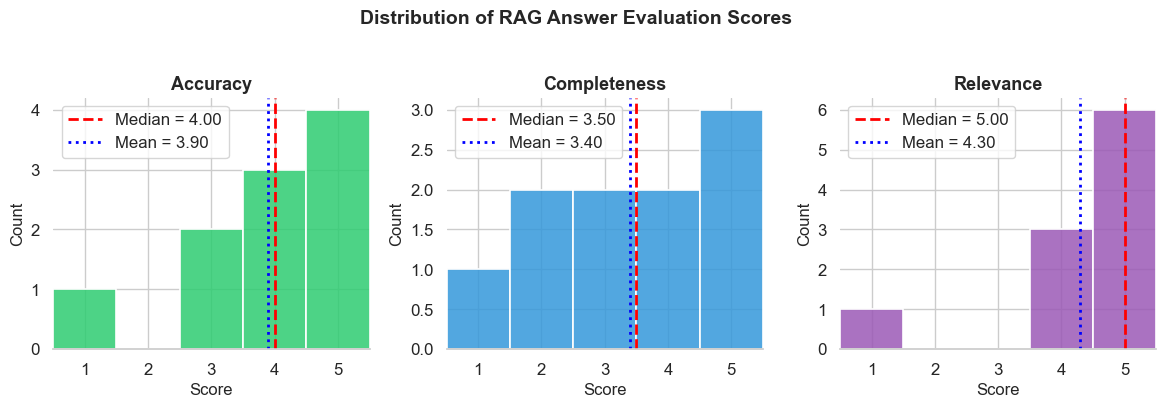

In [12]:
# Distribution plots of answer scores
df_scores = pd.DataFrame({
    "Score": accuracies + completenesses + relevances,
    "Metric": ["Accuracy"] * len(accuracies) + ["Completeness"] * len(completenesses) + ["Relevance"] * len(relevances),
})

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
palette = {"Accuracy": "#2ecc71", "Completeness": "#3498db", "Relevance": "#9b59b6"}

for ax, metric in zip(axes, ["Accuracy", "Completeness", "Relevance"]):
    data = df_scores[df_scores["Metric"] == metric]["Score"]
    sns.histplot(data=data, bins=np.arange(0.5, 6, 1), color=palette[metric], edgecolor="white",
                linewidth=1.2, alpha=0.85, ax=ax)
    median = np.median(data)
    mean = np.mean(data)
    # Median line: red dashed, Average line: blue dotted
    ax.axvline(median, color="red", linestyle='--', linewidth=2, label=f"Median = {median:.2f}")
    ax.axvline(mean, color="blue", linestyle=':', linewidth=2, label=f"Mean = {mean:.2f}")
    ax.set_xlabel("Score", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlim(0.5, 5.5)
    ax.legend()

fig.suptitle("Distribution of RAG Answer Evaluation Scores", fontsize=14, fontweight="bold", y=1.02)
sns.despine(left=True)
plt.tight_layout()
plt.show()

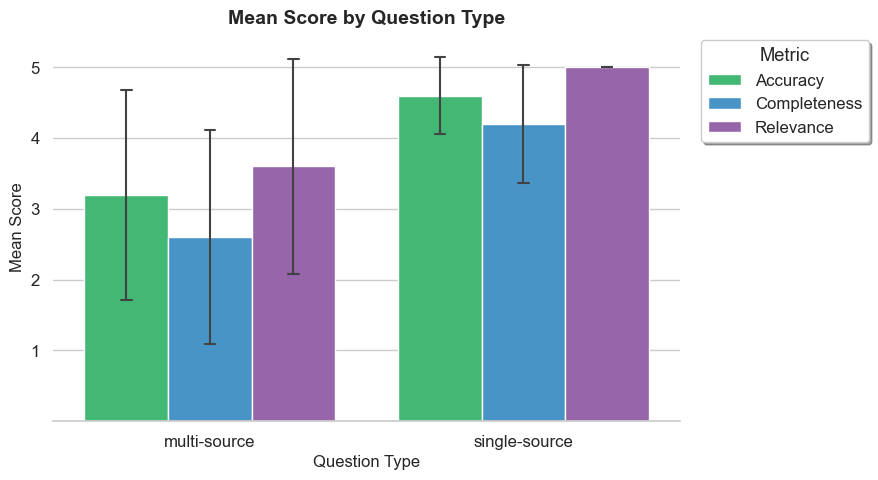

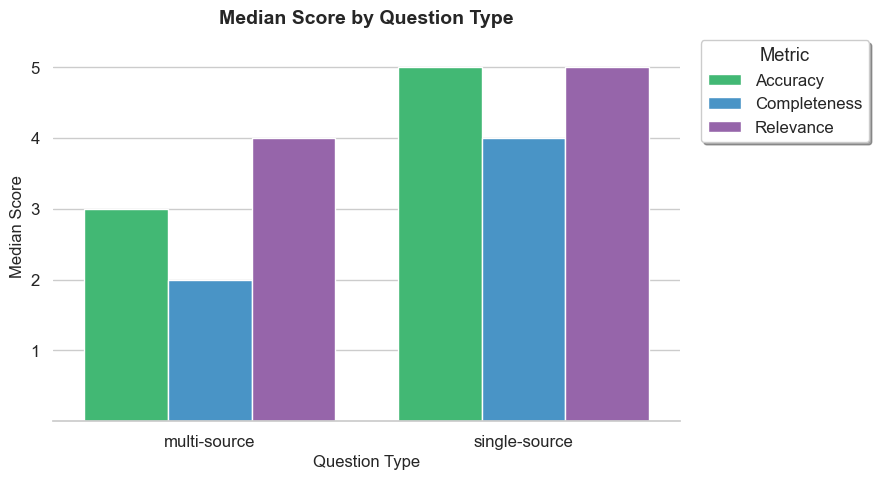

In [13]:
# Performance by question type: mean and median score per metric, grouped by single- vs multi-source
scores_by_type = defaultdict(lambda: {"accuracy": [], "completeness": [], "relevance": []})
for qt, acc, comp, rel in zip(question_types, accuracies, completenesses, relevances):
    scores_by_type[qt]["accuracy"].append(acc)
    scores_by_type[qt]["completeness"].append(comp)
    scores_by_type[qt]["relevance"].append(rel)

types = sorted(scores_by_type.keys())
metrics = ["accuracy", "completeness", "relevance"]
metric_labels = ["Accuracy", "Completeness", "Relevance"]

# Build long-format DataFrame for seaborn
rows = []
for qt in types:
    for m, label in zip(metrics, metric_labels):
        for v in scores_by_type[qt][m]:
            rows.append({"Question Type": qt, "Metric": label, "Score": v})
df = pd.DataFrame(rows)

# 1. Grouped bar chart with seaborn (Mean)
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=df, 
    x="Question Type", 
    y="Score", 
    hue="Metric", 
    palette={"Accuracy": "#2ecc71", "Completeness": "#3498db", "Relevance": "#9b59b6"},
    errorbar="sd", 
    capsize=0.1, 
    err_kws={"linewidth": 1.5}
)
ax.set_ylabel("Mean Score", fontsize=12)
ax.set_xlabel("Question Type", fontsize=12)
ax.set_title("Mean Score by Question Type", fontsize=14, fontweight="bold")
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(title="Metric", frameon=True, fancybox=True, shadow=True, loc="upper left", bbox_to_anchor=(1.02, 1))
sns.despine(left=True)
plt.tight_layout()
plt.show()

# 2. Median bar chart (same structure, but showing median instead of mean)
# Compute medians per question type and metric
median_rows = []
for qt in types:
    for m, label in zip(metrics, metric_labels):
        data = scores_by_type[qt][m]
        if len(data) > 0:
            median_score = np.median(data)
        else:
            median_score = np.nan
        median_rows.append({"Question Type": qt, "Metric": label, "Median Score": median_score})
df_median = pd.DataFrame(median_rows)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=df_median, 
    x="Question Type", 
    y="Median Score",
    hue="Metric", 
    palette={"Accuracy": "#2ecc71", "Completeness": "#3498db", "Relevance": "#9b59b6"},
    capsize=0.1
)
ax.set_ylabel("Median Score", fontsize=12)
ax.set_xlabel("Question Type", fontsize=12)
ax.set_title("Median Score by Question Type", fontsize=14, fontweight="bold")
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(title="Metric", frameon=True, fancybox=True, shadow=True, loc="upper left", bbox_to_anchor=(1.02, 1))
sns.despine(left=True)
plt.tight_layout()
plt.show()